# Projekt 03 (final): EDA — Wer faehrt wann Fahrrad, und warum?

**Szenario:** Du arbeitest fuer das Bikesharing-System **Capital Bikeshare**
(Washington D.C.). Die Betriebsleitung will wissen: *Wovon haengt die Nachfrage ab?
Wann brauchen wir die meisten Raeder? Unterscheiden sich unsere Kundengruppen?*
Deine Aufgabe: eine vollstaendige explorative Datenanalyse (EDA) auf den **echten**
Verleihdaten 2011-2012 (17.379 Stundenwerte) — mit einem Fazit in klaren Saetzen.

**Vorbereitung** (einmalig, im Ordner `03-final`, venv aktiv):

```
python daten/download_daten.py
```

**Arbeitsweise:** Das ist ein Final-Projekt — die Leitfragen sind vorgegeben, den Code
schreibst du weitgehend selbst (Tipps stehen dabei, die Musterloesung in `loesung/`).
Halte dich an den EDA-Workflow aus Skript 2.5: Ueberblick → Qualitaet → univariat →
bivariat → Zeit → Fazit. **Jede Grafik bekommt einen Interpretationssatz.**

## 1. Ueberblick & Dokumentation

Spalten (aus der offiziellen Dataset-Beschreibung):

| Spalte | Bedeutung |
|--|--|
| `dteday`, `hr` | Datum, Stunde (0-23) |
| `season` | 1 Winter, 2 Fruehling, 3 Sommer, 4 Herbst |
| `yr` | 0 = 2011, 1 = 2012 |
| `holiday`, `weekday`, `workingday` | Feiertag, Wochentag (0 = So), Arbeitstag |
| `weathersit` | 1 klar, 2 Nebel/Wolken, 3 leichter Regen/Schnee, 4 Unwetter |
| `temp`, `atemp` | Temperatur / gefuehlt — **normiert!** `temp*41` = Grad C, `atemp*50` = Grad C |
| `hum`, `windspeed` | Luftfeuchte (`*100` = %), Wind (`*67` = km/h) — normiert |
| `casual`, `registered`, `cnt` | Gelegenheitsnutzer, registrierte Nutzer, Summe |

**Aufgabe:** Lade `daten/hour.csv`, mach die Erstinspektion (`shape`, `head`, `info`)
und lege **entnormierte** Spalten an: `temp_c`, `hum_pct`, `wind_kmh`.
*(Lektion: Ohne die Doku haettest du "Temperaturen" zwischen 0 und 1 analysiert.)*

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PFAD = "daten/hour.csv" if os.path.exists("daten/hour.csv") else "../daten/hour.csv"
df = pd.read_csv(PFAD, parse_dates=["dteday"])
df["temp_c"] = df["temp"] * 41
df["hum_pct"] = df["hum"] * 100
df["wind_kmh"] = df["windspeed"] * 67
print(df.shape)
df[["dteday", "hr", "weathersit", "temp_c", "hum_pct", "cnt"]].head()

(17379, 20)


,dteday,hr,weathersit,temp_c,hum_pct,cnt
0,2011-01-01,0,1,9.84,81.0,16
1,2011-01-01,1,1,9.02,80.0,40
2,2011-01-01,2,1,9.02,80.0,32
3,2011-01-01,3,1,9.84,75.0,13
4,2011-01-01,4,1,9.84,75.0,1


## 2. Datenqualitaet

**Aufgaben:**
1. Fehlende Werte? Duplikate? (Spoiler: der Datensatz ist gepflegt — aber pruefen!)
2. Konsistenz: Gilt ueberall `cnt == casual + registered`?
3. **Die versteckte Luecke:** 2011-2012 haben 17.544 Stunden, der Datensatz hat 17.379
   Zeilen. Fehlen Stunden — und wenn ja, wie viele? (Tipp: vollstaendigen Stundenindex
   mit `pd.date_range(..., freq="h")` bauen und vergleichen.)

In [2]:
print("fehlende Werte:", df.isna().sum().sum())
print("Duplikate:", df.duplicated().sum())
print("cnt == casual + registered:", (df["cnt"] == df["casual"] + df["registered"]).all())

voll = pd.date_range("2011-01-01", "2012-12-31 23:00", freq="h")
print(f"erwartet: {len(voll)} Stunden, vorhanden: {len(df)}, fehlend: {len(voll) - len(df)}")

fehlende Werte: 0
Duplikate: 0
cnt == casual + registered: True
erwartet: 17544 Stunden, vorhanden: 17379, fehlend: 165


**Befund:** Keine NaN, keine Duplikate, `cnt` konsistent — aber **165 Stunden fehlen
komplett** (Betriebsausfaelle/Wartung). Fuer unsere Mittelwert-Analysen ist das
unkritisch; fuer eine lueckenlose Zeitreihenanalyse (spaeteres Modul) muesste man die
Luecken explizit behandeln. **Merke: „keine NaN" heisst nicht „nichts fehlt" —
fehlende ZEILEN sieht nur, wer danach sucht.**

## 3. Univariat: die Zielgroesse verstehen

**Aufgaben:**
1. Histogramm von `cnt` (Ausleihen pro Stunde) — beschreibe die Form.
2. Kennzahlen: Mittel vs. Median — passt das zur Form? (Skript 1.3!)

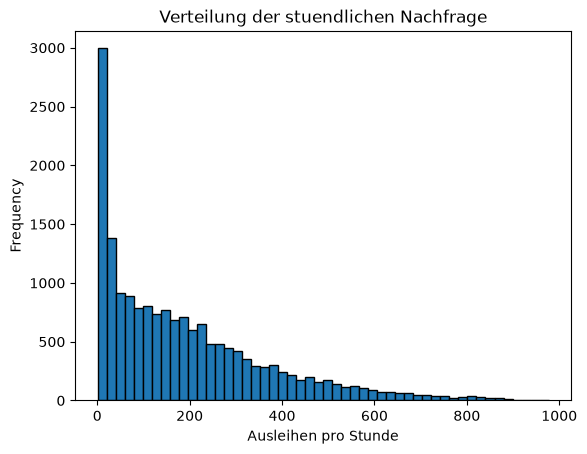

count    17379.0
mean       189.5
std        181.4
min          1.0
25%         40.0
50%        142.0
75%        281.0
max        977.0
Name: cnt, dtype: float64

Mittel 189 > Median 142 -> rechtsschief


In [3]:
df["cnt"].plot.hist(bins=50, edgecolor="black")
plt.xlabel("Ausleihen pro Stunde"); plt.title("Verteilung der stuendlichen Nachfrage")
plt.show()
print(df["cnt"].describe().round(1))
print(f"\nMittel {df['cnt'].mean():.0f} > Median {df['cnt'].median():.0f} -> rechtsschief")

**Interpretation:** Stark **rechtsschief** — viele ruhige Stunden (Nacht!), wenige
Spitzenstunden bis fast 1000 Ausleihen. Mittel (189) > Median (142), wie es das
Skript fuer rechtsschiefe Verteilungen vorhersagt. Fuer „typische Stunde" ist der
Median die ehrlichere Zahl.

## 4. Zeitmuster — die Kernfrage des Betriebs

**Aufgaben:**
1. Mittlere Ausleihen pro Stunde (`groupby("hr")`) — als Linienplot.
2. Dasselbe getrennt nach `workingday` (0/1) — zwei Linien in einem Plot.
   (Tipp: `df.groupby(["hr", "workingday"])["cnt"].mean().unstack()`)
3. Beschreibe die Muster: Wann sind die Spitzen? Warum unterscheiden sie sich?

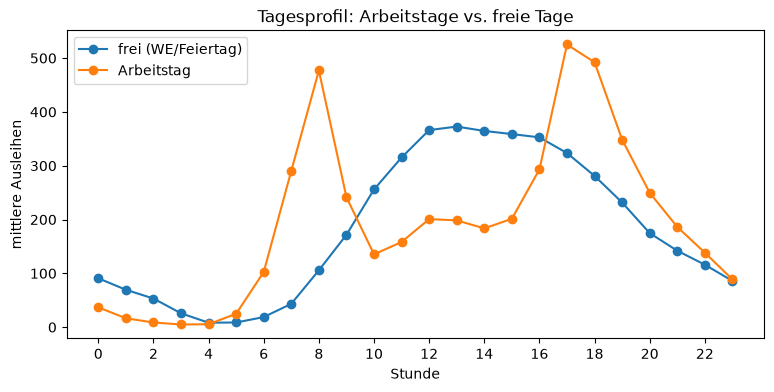

In [4]:
profil = df.groupby(["hr", "workingday"])["cnt"].mean().unstack()
profil.columns = ["frei (WE/Feiertag)", "Arbeitstag"]
profil.plot(figsize=(9, 4), marker="o")
plt.xlabel("Stunde"); plt.ylabel("mittlere Ausleihen")
plt.title("Tagesprofil: Arbeitstage vs. freie Tage"); plt.xticks(range(0, 24, 2))
plt.show()

**Interpretation — der wichtigste Plot des Projekts:** An **Arbeitstagen** zwei
scharfe Spitzen um **8 Uhr** (~480) und **17-18 Uhr** (~525/460): Pendlerverkehr.
An **freien Tagen** ein einziger flacher Buckel am Nachmittag: Freizeitverkehr.
Das sind zwei voellig verschiedene Nutzungsarten in einem System — Kapazitaet und
Rebalancing muessen sich nach dem Arbeitstagsprofil richten.

## 5. Zwei Kundengruppen: casual vs. registered

**Aufgabe:** Wiederhole das Stundenprofil, aber vergleiche `casual` und `registered`
(nur Arbeitstage). Welche Gruppe erzeugt die Pendlerspitzen? Was bedeutet das fuer
Marketing (wen erreicht man wann)?

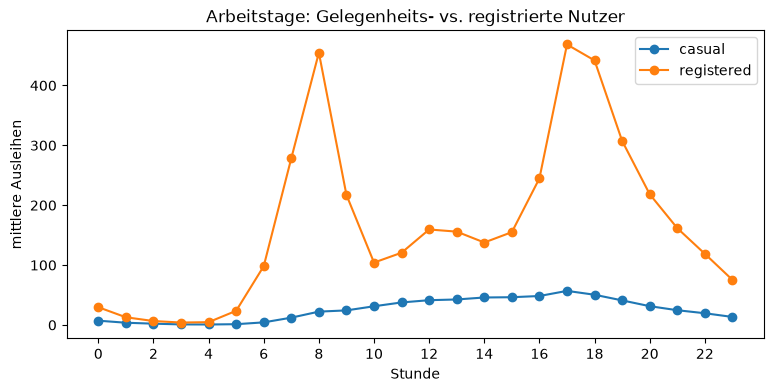

In [5]:
arbeitstage = df[df["workingday"] == 1]
arbeitstage.groupby("hr")[["casual", "registered"]].mean().plot(figsize=(9, 4), marker="o")
plt.xlabel("Stunde"); plt.ylabel("mittlere Ausleihen")
plt.title("Arbeitstage: Gelegenheits- vs. registrierte Nutzer"); plt.xticks(range(0, 24, 2))
plt.show()

**Interpretation:** Die Pendlerspitzen stammen fast vollstaendig von **registrierten**
Nutzern (Abos = Alltagsverkehr). **Casual**-Nutzer fahren flach ueber den Nachmittag
verteilt — Touristen/Freizeit. Zwei Kundengruppen, zwei Ansprachen.

## 6. Wetter

**Aufgaben:**
1. Scatterplot `temp_c` vs. `cnt` (alpha klein waehlen, 17k Punkte!) und
   Pearson-Korrelation.
2. Boxplot `cnt` nach `weathersit`. Achtung: Wie oft kommt Kategorie 4 vor?
   (`value_counts()`) — was bedeutet das fuer die Aussagekraft dieser Box?

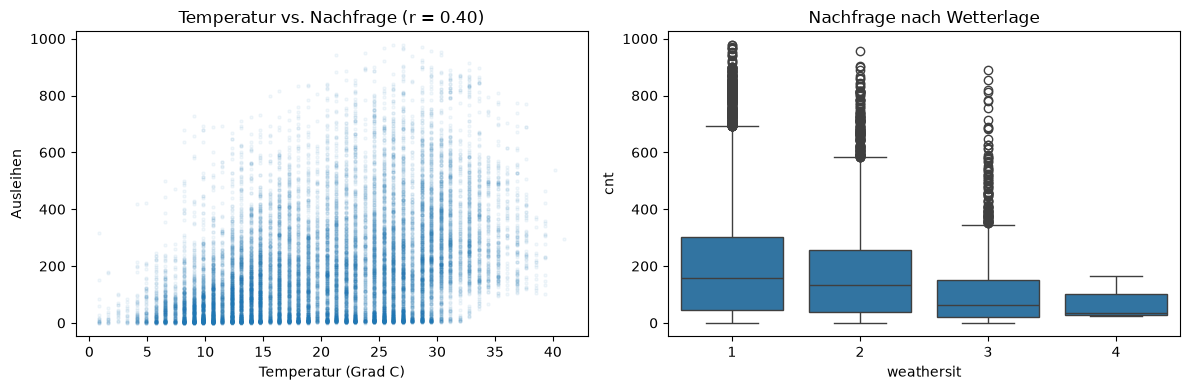

weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64


In [6]:
fig, achsen = plt.subplots(1, 2, figsize=(12, 4))
achsen[0].scatter(df["temp_c"], df["cnt"], alpha=0.05, s=5)
achsen[0].set_xlabel("Temperatur (Grad C)"); achsen[0].set_ylabel("Ausleihen")
r = df["temp_c"].corr(df["cnt"])
achsen[0].set_title(f"Temperatur vs. Nachfrage (r = {r:.2f})")
sns.boxplot(data=df, x="weathersit", y="cnt", ax=achsen[1])
achsen[1].set_title("Nachfrage nach Wetterlage")
plt.tight_layout(); plt.show()
print(df["weathersit"].value_counts().sort_index())

**Interpretation:** Temperatur korreliert positiv (r ≈ 0,40) — aber der Scatter
zeigt: bei JEDER Temperatur gibt es auch nachfrageschwache Stunden (naemlich nachts).
Die Stunde des Tages ueberlagert den Wettereffekt. Schlechteres Wetter senkt die
Nachfrage sichtbar; **Kategorie 4 (Unwetter) kommt aber nur 3-mal vor** — dieser
Boxplot ist statistisch wertlos (n = 3!). Immer Gruppengroessen pruefen, bevor man
Boxplots vergleicht.

## 7. Die Aggregations-Lektion

**Aufgabe:** Berechne r(Temperatur, Ausleihen) noch einmal — aber auf **Tagesebene**
(`day.csv` liegt schon im daten-Ordner, oder aggregiere selbst per `groupby("dteday")`).
Vergleiche mit dem Stundenwert von oben. Warum ist der Tageswert so viel hoeher?

In [7]:
tage = df.groupby("dteday").agg(cnt=("cnt", "sum"), temp_c=("temp_c", "mean"))
r_tag = tage["temp_c"].corr(tage["cnt"])
print(f"r auf Stundenebene: {df['temp_c'].corr(df['cnt']):.3f}")
print(f"r auf Tagesebene:   {r_tag:.3f}")

r auf Stundenebene: 0.405
r auf Tagesebene:   0.627


**Interpretation:** r springt von **0,41 auf 0,63**. Auf Stundenebene verrauscht der
Tag-Nacht-Zyklus den Zusammenhang (3-Uhr-Stunden sind immer leer, egal wie warm).
Auf Tagesebene mittelt sich das heraus. **Lehre: Korrelationen haengen von der
Aggregationsebene ab** — „die" Korrelation zwischen zwei Groessen gibt es nicht,
man muss dazu sagen, was eine Beobachtung ist (verwandt mit Simpson, Skript 3.2).

## 8. Dein Fazit an die Betriebsleitung

**Aufgabe:** Schreibe hier 5 Bullet-Points in Alltagssprache (keine Fachbegriffe!),
die die wichtigsten Befunde zusammenfassen — so, wie du sie der Betriebsleitung
in einer E-Mail schicken wuerdest.

*Deine Antwort:*

- …

<details><summary>Musterfazit (erst selbst formulieren!)</summary>

- Die Nachfrage wird von Pendlern dominiert: werktags zwei scharfe Spitzen um 8 und 17-18 Uhr — dann muessen Raeder an Bahnhoefen/Bueros stehen.
- Am Wochenende verschiebt sich alles auf den Nachmittag und in die Parks/Freizeitgebiete — das Umverteilen der Raeder muss werktags anders laufen als am Wochenende.
- Registrierte Nutzer = Pendler, Gelegenheitsnutzer = Freizeit/Touristen. Abo-Werbung morgens an Verkehrsknoten, Tagestickets mittags an Sehenswuerdigkeiten.
- Waerme und gutes Wetter treiben die Nachfrage deutlich (auf Tagesbasis einer der staerksten Faktoren) — Wettervorhersage gehoert in die Kapazitaetsplanung.
- Das Geschaeft waechst stark: 2012 lag ~65 % ueber 2011. Kapazitaet fuer die naechste Saison entsprechend planen.
</details>

## Geschafft — was du jetzt kannst

- eine komplette EDA nach Workflow durchfuehren: Ueberblick → Qualitaet → univariat →
  bivariat → Zeit → Fazit
- Dokumentation lesen und normierte Variablen erkennen (temp*41!)
- versteckte Datenluecken finden (fehlende Zeilen statt NaN)
- Muster in Zeitreihen entdecken und **inhaltlich** erklaeren (Pendler!)
- Korrelationen kritisch einordnen (Aggregationsebene, Gruppengroessen)
- Ergebnisse adressatengerecht zusammenfassen

**Bonusaufgaben:**
1. Feiertage: Verhaelt sich ein Feiertag-Montag wie ein Sonntag? (`holiday`)
2. Luftfeuchte und Wind: lohnt sich eine dieser Variablen als Nachfrage-Indikator?
3. Baue eine Korrelationsmatrix (`df[[...]].corr()`, `sns.heatmap`) — und benenne
   eine Korrelation darin, die NICHT kausal zu deuten ist.